LYNN NJERI KAMAU , WTF/2025/4448, klynn3520@outlook.com

In [8]:
import pandas as pd
import numpy as np
import csv
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
Employee_df = pd.read_csv('/content/drive/MyDrive/Python files/HR_comma_sep 1.csv')
Employee_df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


Exploratory data analysis to figure out which variables have direct and clear impact on employee retention (i.e. whether they leave the company or continue to work)

In [5]:
Employee_df['left'].value_counts()

,count
left,
0,11428
1,3571


In [6]:
Employee_df['left'].value_counts(normalize=True) * 100

,proportion
left,
0,76.191746
1,23.808254


The above analysis shows that 76.19% of the employees stayed while 23.80 left.

Summary Statistics

In [22]:
num_cols = [
    'satisfaction_level',
    'last_evaluation',
    'number_project',
    'average_montly_hours',
    'time_spend_company',
    'Work_accident',
    'promotion_last_5years'
    ]

Employee_df.groupby('left')[num_cols].mean().T

left,0,1
satisfaction_level,0.666810,0.440098
last_evaluation,0.715473,0.718113
number_project,3.786664,3.855503
average_montly_hours,199.060203,207.419210
time_spend_company,3.380032,3.876505
Work_accident,0.175009,0.047326
promotion_last_5years,0.026251,0.005321


The statistics show a significant mean difference between the employees who stayed and those who left. Those who left, had low satisfaction levels, worked more hours, did more projets, spent more time in the organization compared with those who stayed.


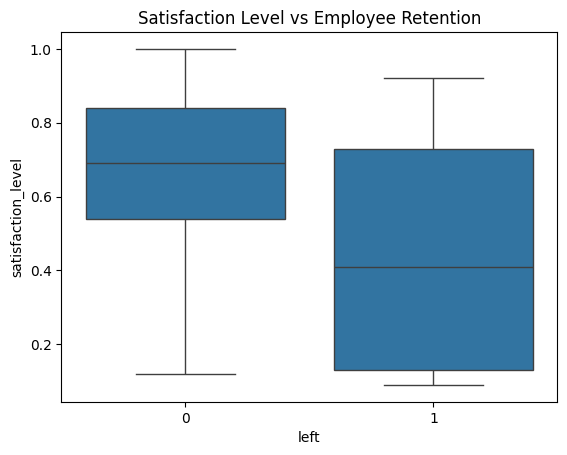

In [9]:
sns.boxplot(x= 'left', y='satisfaction_level', data = Employee_df)
plt.title("Satisfaction Level vs Employee Retention")
plt.show()

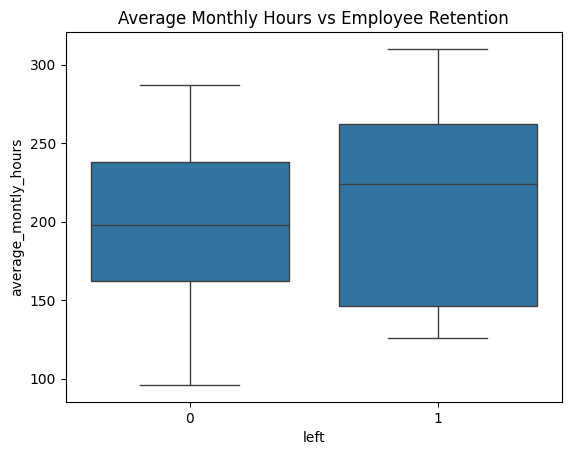

In [11]:
sns.boxplot(x= 'left', y='average_montly_hours', data = Employee_df)
plt.title("Average Monthly Hours vs Employee Retention")
plt.show()

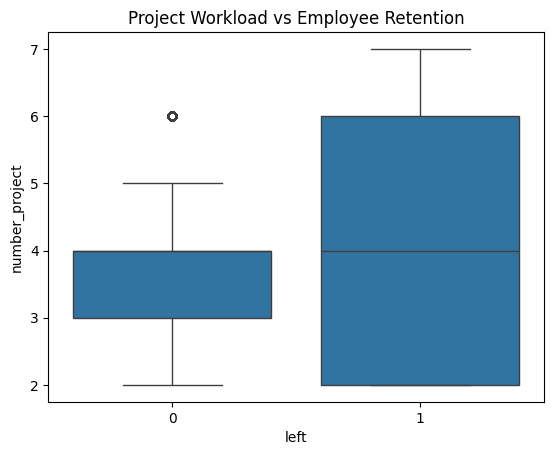

In [12]:
sns.boxplot(x= 'left', y='number_project', data = Employee_df)
plt.title("Project Workload vs Employee Retention")
plt.show()

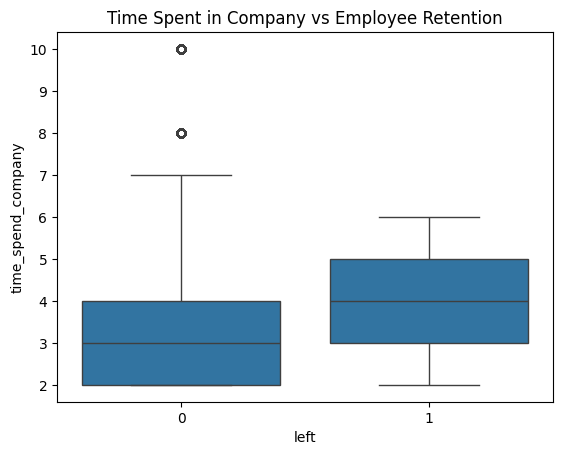

In [13]:
sns.boxplot(x= 'left', y='time_spend_company', data = Employee_df)
plt.title("Time Spent in Company vs Employee Retention")
plt.show()

<Axes: xlabel='left', ylabel='Work_accident'>

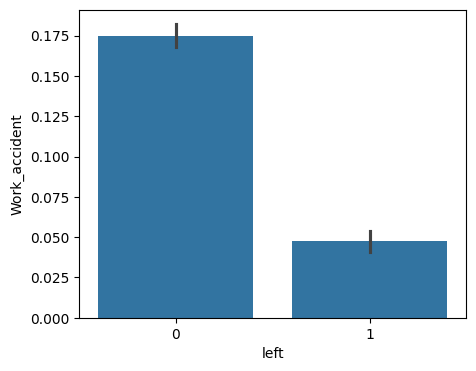

In [15]:
plt.figure(figsize=(5,4))
sns.barplot(
    x= 'left',
    y= 'Work_accident',
    data=Employee_df
)

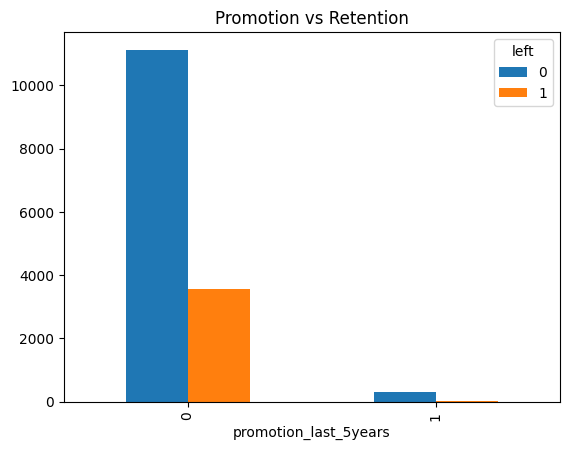

In [18]:
pd.crosstab(Employee_df.promotion_last_5years, Employee_df.left).plot(kind='bar')
plt.title("Promotion vs Retention")
plt.show()

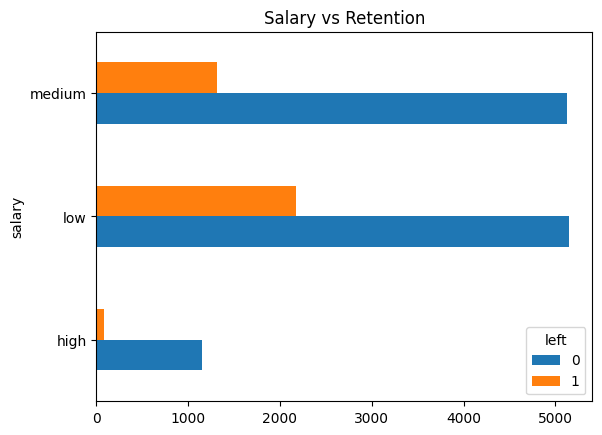

In [36]:

pd.crosstab(Employee_df.salary, Employee_df.left).plot(kind='barh')
plt.title("Salary vs Retention")
plt.show()


pd.crosstab(Employee_df.Department, Employee_df.left).plot(kind='bar', figsize=(10,6), palette='Blues')
plt.title("Department vs Retention")
plt.show()
     

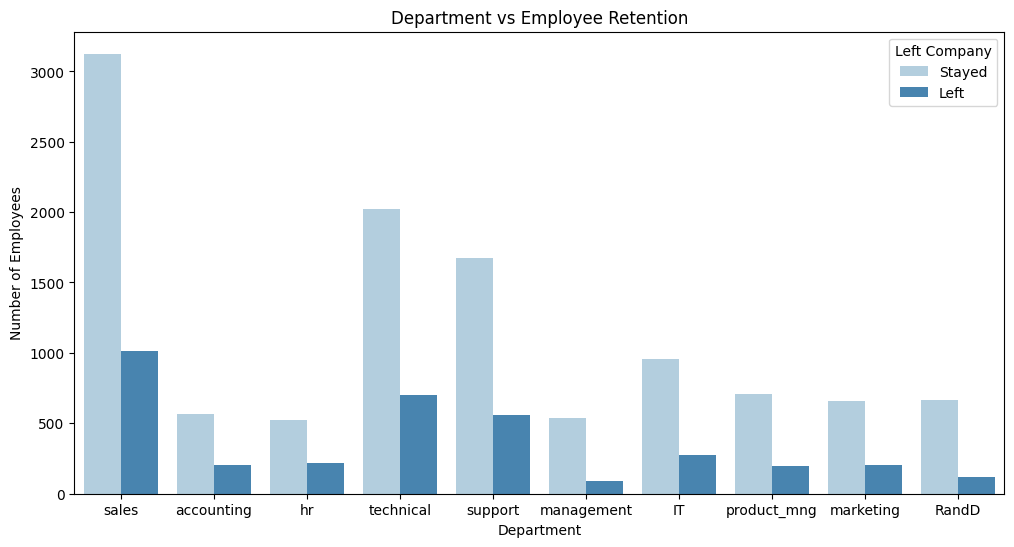

In [34]:
plt.figure(figsize=(12,6))
sns.countplot(data=Employee_df, x='Department', hue='left', palette='Blues')
plt.title("Department vs Employee Retention")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.legend(title="Left Company", labels=["Stayed", "Left"])
plt.show()

***Employee satisfaction is the major variable affecting retention. Other variables with a direct and clear impact include number of projects, average monthly hours, and salary.***

**Plot bar charts showing impact of employee salaries on retention**


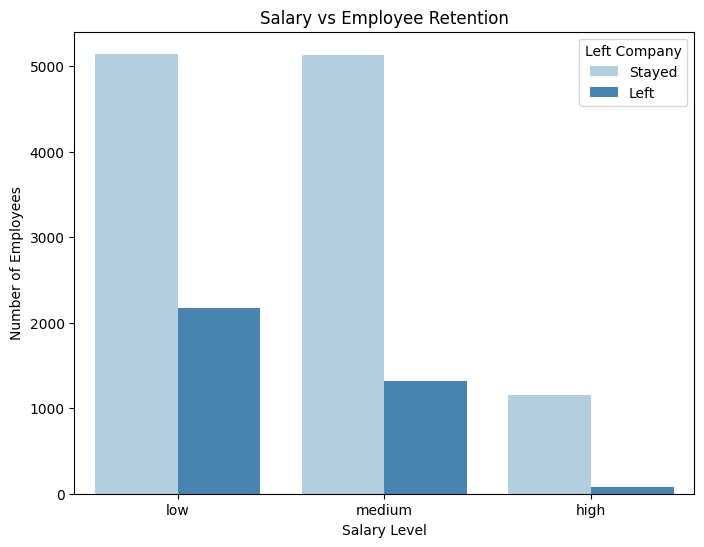

In [29]:
plt.figure(figsize=(8,6))
sns.countplot(data=Employee_df, x='salary', hue='left', palette='Blues')
plt.title("Salary vs Employee Retention")
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.legend(title="Left Company", labels=["Stayed", "Left"])
plt.show()

**Plot bar charts showing corelation between department and employee retention**

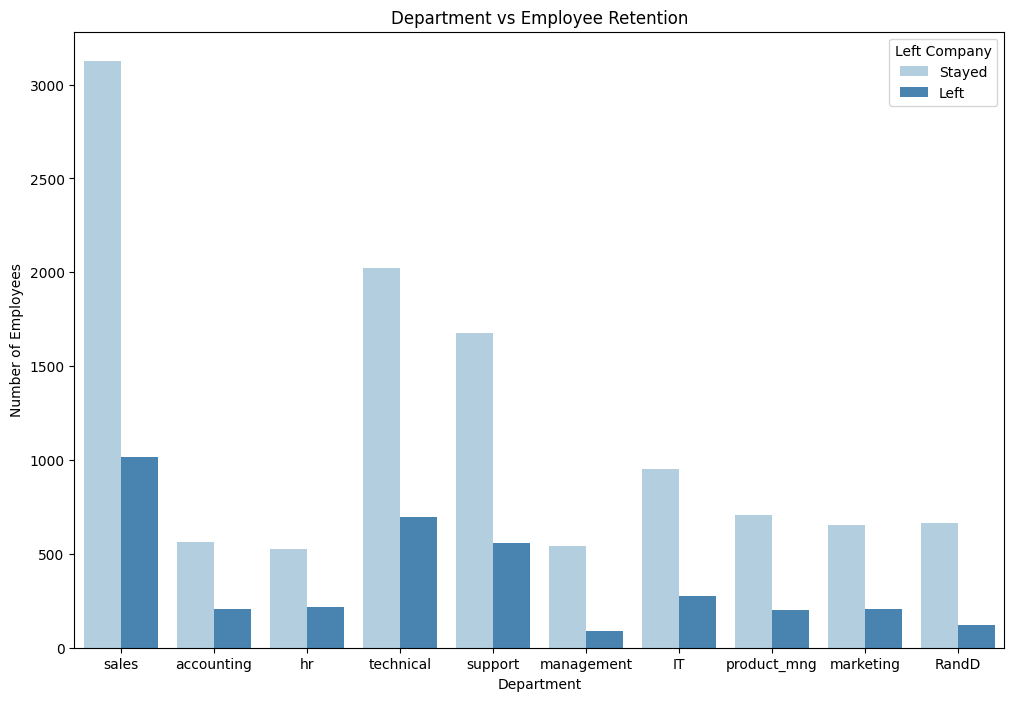

In [30]:
plt.figure(figsize=(12,8))
sns.countplot(data=Employee_df, x='Department', hue='left', palette='Blues')
plt.title("Department vs Employee Retention")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.legend(title="Left Company", labels=["Stayed", "Left"])
plt.show()

**Now build logistic regression model using variables that were narrowed down in step 1**

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [49]:
X = Employee_df[['satisfaction_level',
        'average_montly_hours',
        'number_project',
        'promotion_last_5years',
        ]]

y = Employee_df['left']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7)
X_train

,satisfaction_level,average_montly_hours,number_project,promotion_last_5years
4911,0.78,224,3,0
12067,0.90,264,4,0
11852,0.53,240,4,0
3901,0.73,150,5,0
1532,0.75,245,4,0
...,...,...,...,...
4763,0.23,245,5,0
7853,0.86,147,4,0
1709,0.10,269,6,0
907,0.09,291,6,0


In [51]:
y_train

,left
4911,0
12067,1
11852,0
3901,0
1532,1
...,...
4763,0
7853,0
1709,1
907,1


In [52]:
X_test

,satisfaction_level,average_montly_hours,number_project,promotion_last_5years
7427,0.86,271,3,0
1784,0.43,149,2,0
2257,0.99,215,3,0
14372,0.90,243,5,0
12573,0.36,148,2,0
...,...,...,...,...
11615,0.87,225,4,0
12669,0.72,153,3,0
5467,0.56,238,3,0
6956,0.79,168,4,0


In [53]:
y_test

,left
7427,0
1784,1
2257,0
14372,1
12573,1
...,...
11615,0
12669,1
5467,0
6956,0


In [54]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [55]:
model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0])

In [56]:

model.predict_proba(X_test)

array([[0.8630211 , 0.1369789 ],
       [0.62299307, 0.37700693],
       [0.93396132, 0.06603868],
       ...,
       [0.69037499, 0.30962501],
       [0.9100754 , 0.0899246 ],
       [0.69634781, 0.30365219]])

In [57]:
model.coef_

array([[-4.02335746,  0.00509903, -0.23037852, -1.4045797 ]])

**Measure the accuracy of the model**

In [58]:
model.score(X_test, y_test)

0.7797777777777778